In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

In [3]:
class CNN(nn.Module):
    def __init__(self, activation='relu', use_bn=False, dropout=0.25):
        super(CNN, self).__init__()
        
        act = {
            'relu': nn.ReLU(),
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh()
        }[activation]

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)
        self.bn = nn.BatchNorm2d(64) if use_bn else nn.Identity()
        self.drop = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64*12*12, 128)
        self.fc2 = nn.Linear(128, 10)
        self.act = act

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.pool(x)
        x = self.bn(x)
        x = self.drop(x)
        x = x.view(x.size(0), -1)
        x = self.act(self.fc1(x))
        return self.fc2(x)

In [4]:
def train(model, optimizer, epochs):
    criterion = nn.CrossEntropyLoss()
    train_loss, test_acc = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss.append(total_loss)

        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x).argmax(dim=1)
                correct += (pred == y).sum().item()

        acc = correct / len(test_data)
        test_acc.append(acc)

        print(f"Epoch {epoch+1}: Loss={total_loss:.2f}, Accuracy={acc:.4f}")

    return train_loss, test_acc

In [5]:
activations = ['sigmoid', 'tanh', 'relu']
activation_results = {}

for act in activations:
    print("\nActivation:", act)
    model = CNN(activation=act).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    loss, acc = train(model, optimizer, epochs=10)
    activation_results[act] = (loss, acc)


Activation: sigmoid
Epoch 1: Loss=8375.37, Accuracy=0.6725
Epoch 2: Loss=2513.92, Accuracy=0.8910
Epoch 3: Loss=1346.89, Accuracy=0.9083
Epoch 4: Loss=1115.74, Accuracy=0.9269
Epoch 5: Loss=976.77, Accuracy=0.9312
Epoch 6: Loss=868.60, Accuracy=0.9404
Epoch 7: Loss=786.27, Accuracy=0.9470
Epoch 8: Loss=722.47, Accuracy=0.9484
Epoch 9: Loss=669.12, Accuracy=0.9536
Epoch 10: Loss=620.91, Accuracy=0.9549

Activation: tanh
Epoch 1: Loss=1171.81, Accuracy=0.9558
Epoch 2: Loss=481.59, Accuracy=0.9735
Epoch 3: Loss=304.55, Accuracy=0.9795
Epoch 4: Loss=218.50, Accuracy=0.9835
Epoch 5: Loss=170.73, Accuracy=0.9854
Epoch 6: Loss=138.76, Accuracy=0.9873
Epoch 7: Loss=115.12, Accuracy=0.9883
Epoch 8: Loss=99.87, Accuracy=0.9881
Epoch 9: Loss=82.97, Accuracy=0.9881
Epoch 10: Loss=70.16, Accuracy=0.9891

Activation: relu
Epoch 1: Loss=1087.30, Accuracy=0.9695
Epoch 2: Loss=299.69, Accuracy=0.9830
Epoch 3: Loss=198.73, Accuracy=0.9854
Epoch 4: Loss=151.89, Accuracy=0.9882
Epoch 5: Loss=121.25, Accu

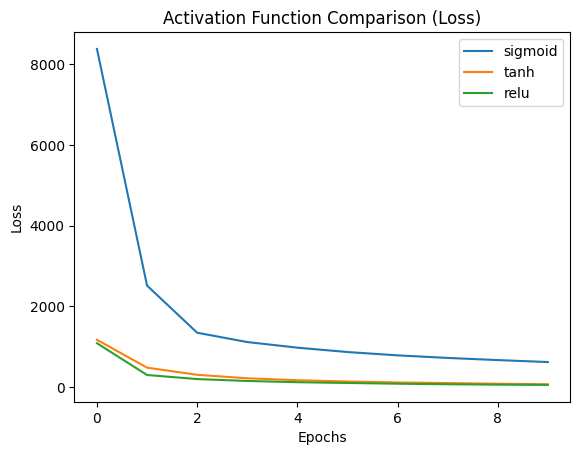

In [6]:
for act in activations:
    plt.plot(activation_results[act][0], label=act)

plt.title("Activation Function Comparison (Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [7]:
optimizers = {
    'SGD': optim.SGD,
    'Momentum': lambda p: optim.SGD(p, lr=0.01, momentum=0.9),
    'Adam': optim.Adam
}

optimizer_results = {}

for name, opt_fn in optimizers.items():
    print("\nOptimizer:", name)
    model = CNN(activation='relu').to(device)
    optimizer = opt_fn(model.parameters())
    loss, acc = train(model, optimizer, epochs=10)
    optimizer_results[name] = acc


Optimizer: SGD
Epoch 1: Loss=3674.67, Accuracy=0.8928
Epoch 2: Loss=1357.80, Accuracy=0.9103
Epoch 3: Loss=1070.45, Accuracy=0.9331
Epoch 4: Loss=848.74, Accuracy=0.9447
Epoch 5: Loss=671.27, Accuracy=0.9578
Epoch 6: Loss=560.33, Accuracy=0.9650
Epoch 7: Loss=472.16, Accuracy=0.9706
Epoch 8: Loss=416.06, Accuracy=0.9714
Epoch 9: Loss=370.64, Accuracy=0.9751
Epoch 10: Loss=334.61, Accuracy=0.9785

Optimizer: Momentum
Epoch 1: Loss=510.30, Accuracy=0.9808
Epoch 2: Loss=177.47, Accuracy=0.9881
Epoch 3: Loss=112.74, Accuracy=0.9879
Epoch 4: Loss=88.35, Accuracy=0.9890
Epoch 5: Loss=68.98, Accuracy=0.9865
Epoch 6: Loss=54.30, Accuracy=0.9898
Epoch 7: Loss=47.37, Accuracy=0.9889
Epoch 8: Loss=35.90, Accuracy=0.9891
Epoch 9: Loss=26.45, Accuracy=0.9904
Epoch 10: Loss=27.49, Accuracy=0.9903

Optimizer: Adam
Epoch 1: Loss=418.30, Accuracy=0.9851
Epoch 2: Loss=162.08, Accuracy=0.9886
Epoch 3: Loss=102.38, Accuracy=0.9893
Epoch 4: Loss=73.29, Accuracy=0.9891
Epoch 5: Loss=55.10, Accuracy=0.9901


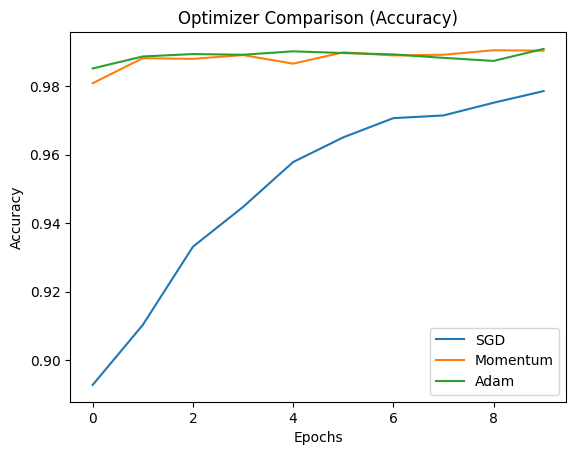

In [8]:
for name in optimizer_results:
    plt.plot(optimizer_results[name], label=name)

plt.title("Optimizer Comparison (Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [9]:
configs = [
    ("No BN No Dropout", False, 0.0),
    ("No BN Dropout 0.1", False, 0.1),
    ("BN Dropout 0.25", True, 0.25)
]

bn_results = {}

for name, bn, dr in configs:
    print("\n", name)
    model = CNN(use_bn=bn, dropout=dr).to(device)
    optimizer = optim.Adam(model.parameters())
    loss, acc = train(model, optimizer, epochs=10)
    bn_results[name] = acc[-1]


 No BN No Dropout
Epoch 1: Loss=395.12, Accuracy=0.9837
Epoch 2: Loss=141.79, Accuracy=0.9872
Epoch 3: Loss=86.29, Accuracy=0.9886
Epoch 4: Loss=57.86, Accuracy=0.9875
Epoch 5: Loss=43.79, Accuracy=0.9883
Epoch 6: Loss=38.71, Accuracy=0.9889
Epoch 7: Loss=32.47, Accuracy=0.9883
Epoch 8: Loss=26.27, Accuracy=0.9897
Epoch 9: Loss=24.47, Accuracy=0.9875
Epoch 10: Loss=18.01, Accuracy=0.9889

 No BN Dropout 0.1
Epoch 1: Loss=399.07, Accuracy=0.9826
Epoch 2: Loss=148.03, Accuracy=0.9866
Epoch 3: Loss=95.94, Accuracy=0.9917
Epoch 4: Loss=64.39, Accuracy=0.9899
Epoch 5: Loss=53.35, Accuracy=0.9897
Epoch 6: Loss=37.21, Accuracy=0.9889
Epoch 7: Loss=37.35, Accuracy=0.9901
Epoch 8: Loss=29.28, Accuracy=0.9904
Epoch 9: Loss=26.92, Accuracy=0.9897
Epoch 10: Loss=24.14, Accuracy=0.9900

 BN Dropout 0.25
Epoch 1: Loss=413.64, Accuracy=0.9846
Epoch 2: Loss=203.69, Accuracy=0.9834
Epoch 3: Loss=140.05, Accuracy=0.9885
Epoch 4: Loss=112.72, Accuracy=0.9883
Epoch 5: Loss=101.18, Accuracy=0.9879
Epoch 6

In [13]:
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        # Find the last Linear layer to get output features
        last_linear = None
        for layer in reversed(layers):
            if isinstance(layer, nn.Linear):
                last_linear = layer
                break
        
        self.model = nn.Sequential(
            nn.Flatten(),
            *layers,
            nn.Linear(last_linear.out_features, 10)
        )

    def forward(self, x):
        return self.model(x)

In [14]:
layers1 = [
    nn.Linear(784, 512), nn.BatchNorm1d(512), nn.ReLU(),
    nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
    nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU()
]

mlp1 = MLP(layers1).to(device)
opt1 = optim.SGD(mlp1.parameters(), lr=0.01)
loss1, acc1 = train(mlp1, opt1, epochs=20)

Epoch 1: Loss=1150.15, Accuracy=0.9716
Epoch 2: Loss=523.63, Accuracy=0.9763
Epoch 3: Loss=369.79, Accuracy=0.9761
Epoch 4: Loss=307.66, Accuracy=0.9788
Epoch 5: Loss=244.44, Accuracy=0.9823
Epoch 6: Loss=213.89, Accuracy=0.9831
Epoch 7: Loss=177.84, Accuracy=0.9830
Epoch 8: Loss=165.48, Accuracy=0.9839
Epoch 9: Loss=137.61, Accuracy=0.9824
Epoch 10: Loss=121.63, Accuracy=0.9821
Epoch 11: Loss=111.35, Accuracy=0.9835
Epoch 12: Loss=110.14, Accuracy=0.9843
Epoch 13: Loss=95.47, Accuracy=0.9849
Epoch 14: Loss=94.50, Accuracy=0.9847
Epoch 15: Loss=88.93, Accuracy=0.9852
Epoch 16: Loss=77.02, Accuracy=0.9834
Epoch 17: Loss=77.88, Accuracy=0.9845
Epoch 18: Loss=66.59, Accuracy=0.9852
Epoch 19: Loss=65.50, Accuracy=0.9856
Epoch 20: Loss=62.69, Accuracy=0.9857


In [15]:
layers2 = [
    nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU()
]

mlp2 = MLP(layers2).to(device)
opt2 = optim.Adam(mlp2.parameters())
loss2, acc2 = train(mlp2, opt2, epochs=15)

Epoch 1: Loss=922.82, Accuracy=0.9690
Epoch 2: Loss=491.79, Accuracy=0.9762
Epoch 3: Loss=384.13, Accuracy=0.9765
Epoch 4: Loss=315.65, Accuracy=0.9775
Epoch 5: Loss=273.47, Accuracy=0.9789
Epoch 6: Loss=243.74, Accuracy=0.9830
Epoch 7: Loss=214.27, Accuracy=0.9804
Epoch 8: Loss=199.97, Accuracy=0.9792
Epoch 9: Loss=176.71, Accuracy=0.9794
Epoch 10: Loss=173.54, Accuracy=0.9812
Epoch 11: Loss=157.00, Accuracy=0.9833
Epoch 12: Loss=139.82, Accuracy=0.9788
Epoch 13: Loss=139.58, Accuracy=0.9813
Epoch 14: Loss=135.62, Accuracy=0.9801
Epoch 15: Loss=122.89, Accuracy=0.9816


In [16]:
results = pd.DataFrame({
    "Model": ["CNN-1", "MLP-1", "MLP-2"],
    "Optimizer": ["Adam", "SGD", "Adam"],
    "Epochs": [10, 20, 15],
    "Final Accuracy": [
        bn_results["BN Dropout 0.25"],
        acc1[-1],
        acc2[-1]
    ]
})

print(results)

   Model Optimizer  Epochs  Final Accuracy
0  CNN-1      Adam      10          0.9894
1  MLP-1       SGD      20          0.9857
2  MLP-2      Adam      15          0.9816
